In [2]:
# DATA MANIPULATION
import pandas as pd
import numpy as np

# PREPROCESSING
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

# DATA VISUALIZATION
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import seaborn as sns

### **Reproducibility**

In [3]:
STUDENT_ID = 25037455
np.random.seed(STUDENT_ID)

# **1. Load and Inspect Data**

In [4]:
# source = https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
  # Your file

In [6]:
data = pd.read_csv("/Users/kamillapena/Desktop/Machine Learn/data.csv", 
                   quotechar='"',  # Handle quoted fields
                   skipinitialspace=True)  # Clean spaces

print("Shape:", data.shape)
data.head()

Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# **2. PREPROCESSING**

## **2.1 SHAPE**

In [7]:
data.shape

(569, 33)

## **2.2 MISSING VALUES**

In [8]:
data.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

## **2.3 DATA TYPES**

In [9]:
data.dtypes

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

## **2.4 STATISTICAL SUMMARY**

In [10]:
# STATISTICAL SUMMARY
print("Statistical Summary (5 key features):")
print(data[['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'diagnosis']].describe())

# WHOLE DATASET
data.describe()

# TWO VARIABLES
data[['radius_mean', 'texture_mean']].describe()

Statistical Summary (5 key features):
       radius_mean  texture_mean  perimeter_mean    area_mean
count   569.000000    569.000000      569.000000   569.000000
mean     14.127292     19.289649       91.969033   654.889104
std       3.524049      4.301036       24.298981   351.914129
min       6.981000      9.710000       43.790000   143.500000
25%      11.700000     16.170000       75.170000   420.300000
50%      13.370000     18.840000       86.240000   551.100000
75%      15.780000     21.800000      104.100000   782.700000
max      28.110000     39.280000      188.500000  2501.000000


,radius_mean,texture_mean
count,569.000000,569.000000
mean,14.127292,19.289649
std,3.524049,4.301036
min,6.981000,9.710000
25%,11.700000,16.170000
50%,13.370000,18.840000
75%,15.780000,21.800000
max,28.110000,39.280000


## **2.5 TARGET DISTRIBUTION (VALUE COUNT)**

In [11]:
print("\nTarget Distribution:")
print(data['diagnosis'].value_counts())

print("\nTarget %:")
print(data['diagnosis'].value_counts(normalize=True) * 100)


Target Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64

Target %:
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


## **DEFINE ONLY NUMERICAL VALUES**

In [12]:
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns.drop('id')

## **2.6 DUPLICATED VALUES**

In [13]:
data.duplicated().value_counts()

False    569
Name: count, dtype: int64

## **2.7 UNIQUE VALUES**

In [14]:
data.nunique()

id                         569
diagnosis                    2
radius_mean                456
texture_mean               479
perimeter_mean             522
area_mean                  539
smoothness_mean            474
compactness_mean           537
concavity_mean             537
concave points_mean        542
symmetry_mean              432
fractal_dimension_mean     499
radius_se                  540
texture_se                 519
perimeter_se               533
area_se                    528
smoothness_se              547
compactness_se             541
concavity_se               533
concave points_se          507
symmetry_se                498
fractal_dimension_se       545
radius_worst               457
texture_worst              511
perimeter_worst            514
area_worst                 544
smoothness_worst           411
compactness_worst          529
concavity_worst            539
concave points_worst       492
symmetry_worst             500
fractal_dimension_worst    535
Unnamed:

## **2.8 CORRELATION MATRIX**

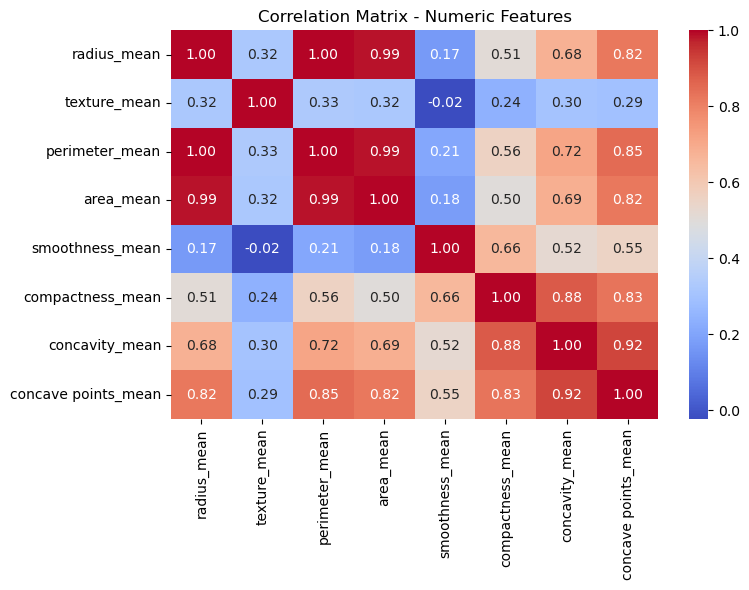

In [15]:
corr_matrix = data[["radius_mean", "texture_mean", "perimeter_mean", 
"area_mean", "smoothness_mean", "compactness_mean", "concavity_mean",
"concave points_mean"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix - Numeric Features')
plt.tight_layout()
plt.show()

# **3. EXPLORATORY DATA ANALYSIS**

## **3.1 DETECT OUTLIERS WITH BOX PLOT**

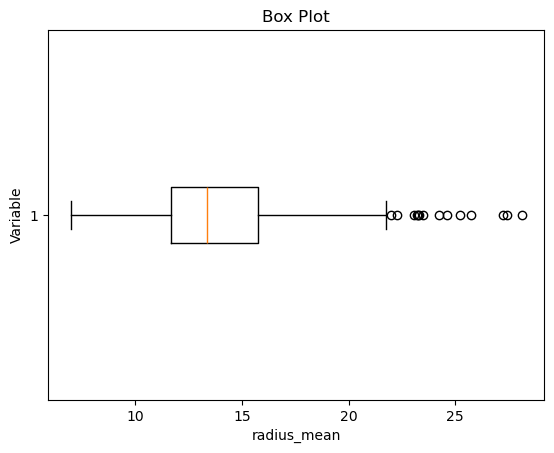

In [16]:
plt.boxplot(data['radius_mean'], vert=False)
plt.ylabel('Variable')
plt.xlabel('radius_mean')
plt.title('Box Plot')
plt.show()

## **3.2 DETECT OUTLIERS WITH BOX PLOT WITH VISUAL CUSTOMIZATION**

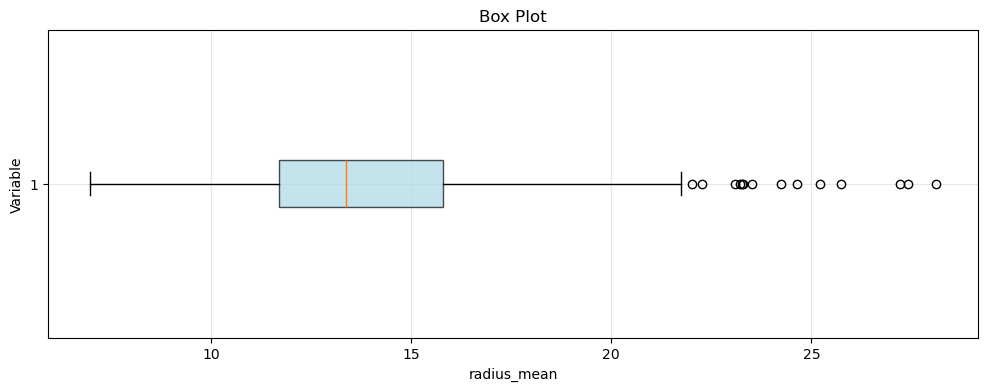

In [17]:
# GRID OF 1x1
fig, ax = plt.subplots(1, 1, figsize=(12, 4), dpi=100)  # 1x1 grid
# box plot with Horizontal
plt.boxplot(data['radius_mean'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7))
plt.ylabel('Variable')
plt.xlabel('radius_mean')  
plt.grid(True, alpha=0.3)  # Grid
plt.title('Box Plot')
plt.show()

## **3.3 DETECT OUTLIERS WITH BOX PLOT OF TWO AXES**

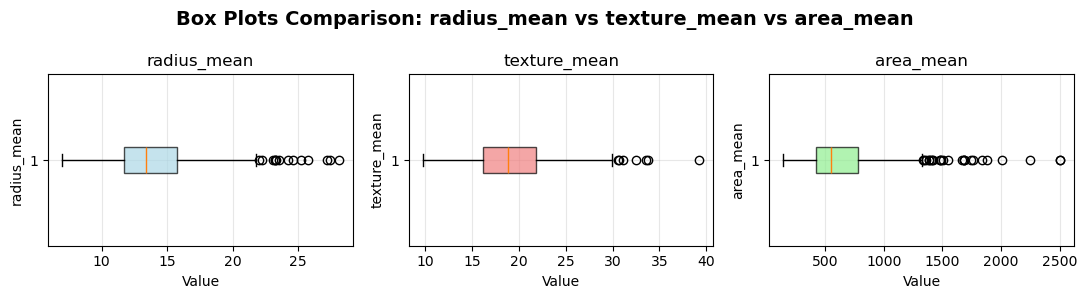

In [18]:
# GRID 1x3
fig, (ax1, ax2, ax3) = plt.subplots(1, # 1 row
                               3, # 3 columns
                               figsize=(11, 3), # Figure Size
                               dpi=100) # Resolution

# AXIS 1
# Variable 1: radius_mean as ax1 first subplot
ax1.boxplot(data['radius_mean'], # Variable
            vert=False, # Vertical or Horizontal
            patch_artist=True, # Colour of box
            boxprops=dict(facecolor='lightblue', alpha=0.7))
ax1.set_ylabel('radius_mean')
ax1.set_xlabel('Value')
ax1.set_title('radius_mean')
ax1.grid(True, alpha=0.3)

# AXIS 2
# Variable 2: texture_mean as ax2 second subplot
ax2.boxplot(data['texture_mean'], 
            vert=False, 
            patch_artist=True,
            boxprops=dict(facecolor='lightcoral', alpha=0.7))
ax2.set_ylabel('texture_mean')
ax2.set_xlabel('Value')
ax2.set_title('texture_mean')
ax2.grid(True, alpha=0.3)

# AXIS 3
# Variable 3: area_mean as ax3 second subplot
ax3.boxplot(data['area_mean'], 
            vert=False, 
            patch_artist=True,
            boxprops=dict(facecolor='lightgreen', alpha=0.7))
ax3.set_ylabel('area_mean')
ax3.set_xlabel('Value')
ax3.set_title('area_mean')
ax3.grid(True, alpha=0.3)

# TITLE
plt.suptitle('Box Plots Comparison: radius_mean vs texture_mean vs area_mean',
fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## **3.4 OUTLIERS BOUNDARIES**

### **3.4.1 REMOVING OUTLIERS MANUALLY**

In [19]:
data2 = data[data['radius_mean'] <= 22].copy()


print(f"Original: {len(data)} rows → Clean: {len(data2)} rows")
print(f"Removed: {len(data) - len(data2)} samples ({((len(data) - len(data2))/len(data)*100):.1f}%)")

Original: 569 rows → Clean: 555 rows
Removed: 14 samples (2.5%)


### **3.4.2 CALCULATING OUTLIERS BOUNDARIES AND REMOVE THEM**

In [20]:
mean = data['texture_mean'].mean()
std = data['texture_mean'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

data = data[(data['texture_mean'] >= lower_bound) 
           & (data['texture_mean'] <= upper_bound)]

### **3.4.3 NEW DATA DISTRIBUTION**

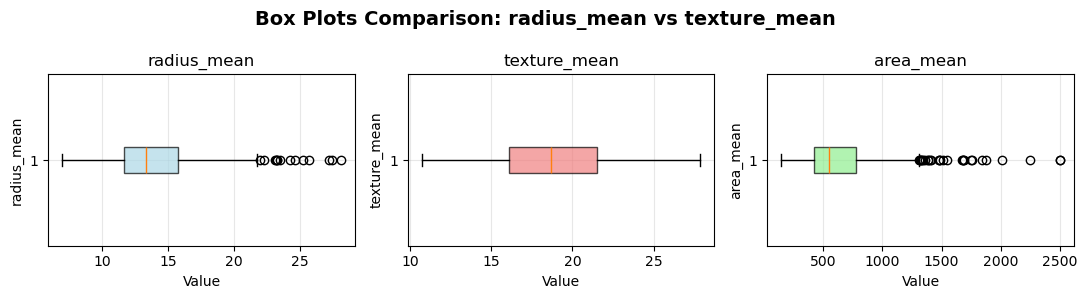

In [21]:
# GRID 1x2
fig, (ax1, ax2, ax3) = plt.subplots(1, # 1 row
                               3, # 2 columns
                               figsize=(11, 3), # Figure Size
                               dpi=100) # Resolution

# AXIS 1
# Variable 1: radius_mean as ax1 first subplot
ax1.boxplot(data['radius_mean'], # Variable
            vert=False, # Vertical or Horizontal
            patch_artist=True, # Colour of box
            boxprops=dict(facecolor='lightblue', alpha=0.7))
ax1.set_ylabel('radius_mean')
ax1.set_xlabel('Value')
ax1.set_title('radius_mean')
ax1.grid(True, alpha=0.3)

# AXIS 2
# Variable 2: texture_mean as ax2 second subplot
ax2.boxplot(data['texture_mean'], 
            vert=False, 
            patch_artist=True,
            boxprops=dict(facecolor='lightcoral', alpha=0.7))
ax2.set_ylabel('texture_mean')
ax2.set_xlabel('Value')
ax2.set_title('texture_mean')
ax2.grid(True, alpha=0.3)

# AXIS 2
# Variable 2: texture_mean as ax2 second subplot
ax3.boxplot(data['area_mean'], 
            vert=False, 
            patch_artist=True,
            boxprops=dict(facecolor='lightgreen', alpha=0.7))
ax3.set_ylabel('area_mean')
ax3.set_xlabel('Value')
ax3.set_title('area_mean')
ax3.grid(True, alpha=0.3)

# TITLE
plt.suptitle('Box Plots Comparison: radius_mean vs texture_mean', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# **4. DATA VISUALIZATION**

## **4.1 BAR PLOTS**

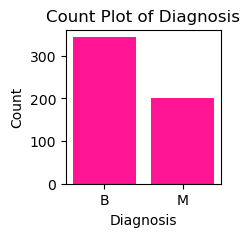

In [22]:
diagnosis_counts = data['diagnosis'].value_counts()

plt.figure(figsize=(2,2))
plt.bar(diagnosis_counts.index, diagnosis_counts, color='deeppink')
plt.title('Count Plot of Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

## **4.2 KERNEL DENSITY PLOTS (Smoothed version of Histogram)**

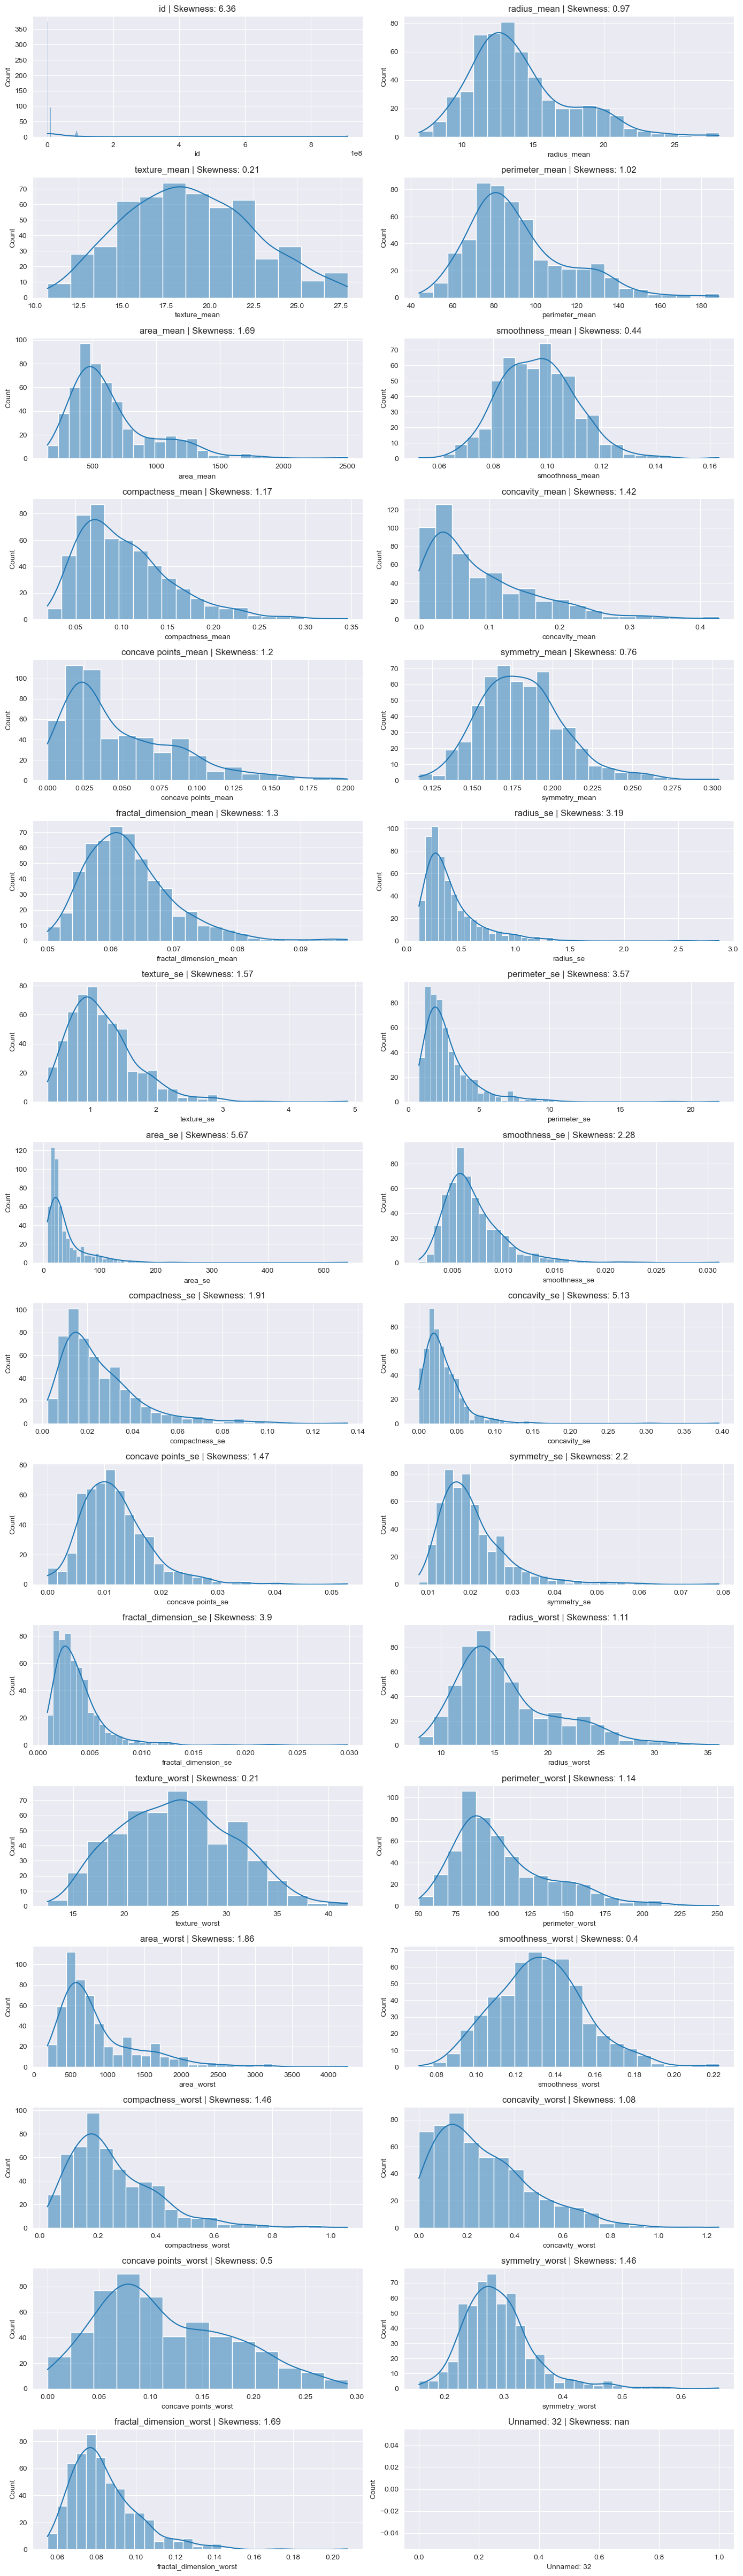

In [23]:
sns.set_style("darkgrid")
numerical_columns = data.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(data[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(data[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

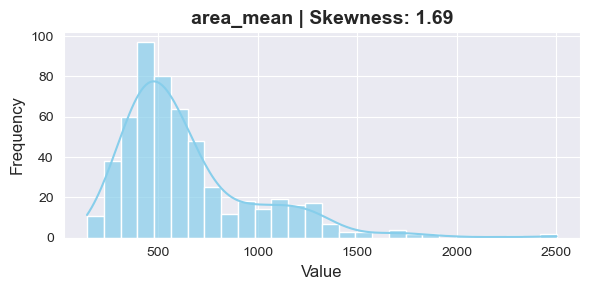

In [24]:
sns.set_style("darkgrid")

plt.figure(figsize=(6, 3)) # Figure Size
sns.histplot(data["area_mean"],  # Feature
             kde=True, # Curve line above the histogram of real distribution
             color='skyblue', 
             alpha=0.7) # Transparency

plt.title(f"area_mean | Skewness: {round(data['area_mean'].skew(), 2)}",
          fontsize=14, fontweight='bold')
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

## **4.3 GROUPS**

### **4.3.1 MAKING GROUPS**

In [25]:
# DIAGNOSIS GROUPS BY MEAN
diagnosis_means = data.groupby('diagnosis')['radius_mean'].mean().round(2)

diagnosis_pmeans = data.groupby('diagnosis')['perimeter_mean'].mean().round(2)


# COLOURS
colors = ['lightgreen' if x == 'B' else 'lightcoral' for x in diagnosis_means.index]

In [26]:
diagnosis_pmeans

diagnosis
B     78.12
M    115.12
Name: perimeter_mean, dtype: float64

## **4.3.2 OVERLAID HISTOGRAM**

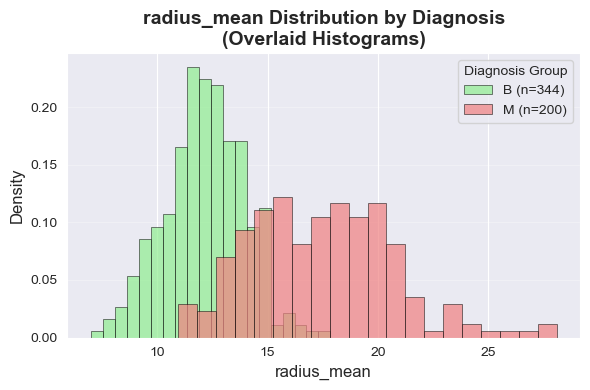

radius_mean by diagnosis:
           count   mean   std
diagnosis                    
B            344  12.15  1.80
M            200  17.43  3.26


In [27]:
# OVERLAID GROUPED HISTOGRAM
fig, ax = plt.subplots(1, 1, figsize=(6, 4)) # 1x1 Grid

# HISTOGRAM BY GROUP
for diagnosis in ['B', 'M']:
    subset = data[data['diagnosis'] == diagnosis]['radius_mean'] # Subset of data
    plt.hist(subset, bins=20, # From the subsets grouped in 20 bins
             alpha=0.7,  # Transparency of bars
             label=f'{diagnosis} (n={len(subset)})', # Labels depending on # labels of subset
             color='lightgreen' if diagnosis == 'B' else 'lightcoral', # Colors of bars
             edgecolor='black', 
             linewidth=0.5, # How wide you need the line of each bar
             density=True)  # density=True to compare forms

plt.title('radius_mean Distribution by Diagnosis\n(Overlaid Histograms)',
 fontsize=14, fontweight='bold')
plt.xlabel('radius_mean', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Diagnosis Group')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# COMPARATIVE STATISTICS
print("radius_mean by diagnosis:")
print(data.groupby('diagnosis')['radius_mean'].agg(['count', 'mean', 'std']).round(2))


## **4.4 PIE CHART**

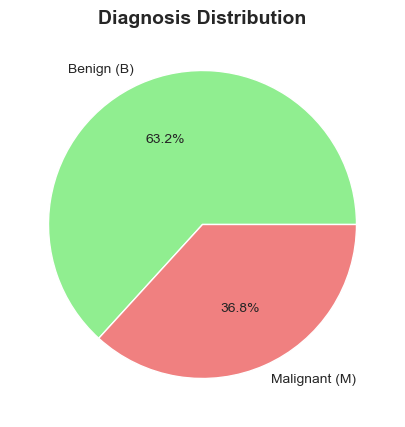

In [28]:
# Target distribution
plt.figure(figsize=(6, 5))
plt.pie(data['diagnosis'].value_counts(), 
        labels=['Benign (B)', 'Malignant (M)'], 
        autopct='%.1f%%', 
        colors=['lightgreen', 'lightcoral'])
plt.title('Diagnosis Distribution', fontsize=14, fontweight='bold')
plt.ylabel('')  # Remove y-label from pie
plt.show()

# **5. DATA PREPARATON**

## **5.1 ENCODING DATA**

In [29]:
data["diagnosis"].head(10)

1     M
2     M
3     M
4     M
5     M
6     M
7     M
8     M
9     M
10    M
Name: diagnosis, dtype: object

In [30]:
diagnosis = data["diagnosis"]

le = LabelEncoder()
diagnosis_encoded  = le.fit_transform(diagnosis)
diagnosis_encoded[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

## **5.2 ONE HOT ENCODING**

In [31]:
diagnosis_onehotencode = pd.DataFrame(data, columns=['diagnosis'])
one_hot_encoded = pd.get_dummies(data["diagnosis"], prefix='diagnosis')

In [32]:
one_hot_encoded.head(10)

,diagnosis_B,diagnosis_M
1,False,True
2,False,True
3,False,True
4,False,True
5,False,True
6,False,True
7,False,True
8,False,True
9,False,True
10,False,True


## **5.3 SEPARATE FEATURES AND TARGET VARIABLE**

In [33]:
X = data.drop(columns=['diagnosis', 'Unnamed: 32', 'id'])
y = data['diagnosis']

In [34]:
X.head(5)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,0.2087,0.07613,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


## **5.4 DATA FORMATTING**


In [35]:
scaler = MinMaxScaler(feature_range=(0, 1))

num_col_ = [col for col in X.columns if X[col].dtype != 'object']
x1 = X
x1[num_col_] = scaler.fit_transform(x1[num_col_])
x1.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
1,0.643144,0.410839,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.344367,0.141323,...,0.606901,0.371935,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,0.601496,0.613636,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.481580,0.211247,...,0.556386,0.444142,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,0.210090,0.562937,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.763481,1.000000,...,0.248310,0.477180,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,0.629893,0.210956,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.342766,0.186816,...,0.519744,0.142371,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595
5,0.258839,0.290210,0.267984,0.141506,0.678613,0.461996,0.369728,0.402038,0.491191,0.551179,...,0.268232,0.383515,0.263908,0.136748,0.712739,0.482784,0.427716,0.598282,0.477035,0.454939


# **6. TRAIN/TEST SPLIT**

## **6.1 NORMAL, CONSIDER THE % OF TRAIN FROM RECORD 1**

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=42, 
                                   test_size=0.2, 
                                   shuffle=False)

In [37]:
X_train.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
1,0.643144,0.410839,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.344367,0.141323,...,0.606901,0.371935,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,0.601496,0.613636,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.481580,0.211247,...,0.556386,0.444142,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,0.210090,0.562937,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.763481,1.000000,...,0.248310,0.477180,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,0.629893,0.210956,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.342766,0.186816,...,0.519744,0.142371,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595
5,0.258839,0.290210,0.267984,0.141506,0.678613,0.461996,0.369728,0.402038,0.491191,0.551179,...,0.268232,0.383515,0.263908,0.136748,0.712739,0.482784,0.427716,0.598282,0.477035,0.454939


## **6.2 SHUFFLE ACTIVATED TO SPLIT WITH RANDOM SHUFFLING**

In [38]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X,y ,
                                   random_state=42, 
                                   test_size=0.8, 
                                   shuffle=True)

In [39]:
X_train2.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
15,0.357755,0.980186,0.365835,0.218579,0.553128,0.429790,0.384021,0.366004,0.606514,0.438290,...,0.339025,0.839237,0.367000,0.186296,0.638117,0.611627,0.561182,0.588316,0.522965,0.518562
157,0.466610,0.509324,0.446479,0.312492,0.196985,0.162107,0.120665,0.137724,0.361452,0.057287,...,0.366062,0.530654,0.348075,0.208120,0.109423,0.139428,0.150319,0.289897,0.189631,0.030697
41,0.187846,0.619464,0.194251,0.096543,0.632572,0.314153,0.244611,0.281759,0.388681,0.394693,...,0.174671,0.778270,0.183326,0.080810,0.790662,0.235284,0.321326,0.489347,0.275774,0.269054
388,0.202991,0.278555,0.204478,0.105408,0.280040,0.282253,0.235942,0.137028,0.343300,0.475147,...,0.146211,0.219346,0.146023,0.065081,0.257743,0.246054,0.241294,0.284261,0.116696,0.323101
189,0.251739,0.301865,0.242139,0.135822,0.254311,0.163027,0.090066,0.082207,0.266951,0.100674,...,0.192814,0.241826,0.180487,0.088847,0.253781,0.133607,0.113658,0.165464,0.180761,0.052604
